In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random # pour faire des tirages aléatoires

In [ ]:
#%% Fonction utilisées dans le script
# Fonction de lecture des données
def read_excel_data(filename, sheet_name):
        data = pd.read_excel(filename, sheet_name=sheet_name, header=None)
        values =  data.values
        return values

# Modèle algébrique de production PV
def Mod_PVprod(Ta, E, Ppv_nom):

    # Paramètre du modèle
    NOCT = 48.
    E_ref = 1000. # Rayonnement de référence [W/m²]
    Tpv_ref = 25. # Température de référence [°C]
    alpha = -4.8e-3

    # à remplir ...
    # (2) Température des modules
    Tpv = Ta + E * (NOCT - 20.0) / 800.0

    # (1) Puissance PV
    Ppv = (E / E_ref) * (Ppv_nom + alpha * (Tpv - Tpv_ref))

    return Ppv

In [ ]:
#%% Paramètres du problème
# Constantes :
deg2K  = 273.15 # Conversion degré en Kelvin
kW2W = 1000. # Conversion kW en W
kWh2Wh = 1000.
h2min = 60 # conversion h -> min
N_ev = 50
capa_bat = 52  # Capacité des batteries [kWh]
d_autonomie = 320 # Autonomie des batteries [km]
P1_ch = 22 # Puissance de recharge [kW] --> Hypothese: recharge normal
vmoy = 40/h2min # Vitesse moyenne en km par min

Ppv_nom = 500e3 # Puissance nominale de l'installation solaire

#%% Chargement des données
j = 174 # Jour de simulation
Nj = 1 # Nombre de jour de simu
ind_0 = j*24+1 # commence à 1h
ind_f = (j+Nj)*24 + 1 # termine à minuit

filename = 'TP-V2G-Input_data.xlsx'
sheet_name = "Demands"
Hd = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,1].tolist())*kW2W
Pd = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,2].tolist())*kW2W
v_tps_h = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,0].tolist())*h2min

sheet_name = "Meteo"
E = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,1].tolist())
Ta = np.array(read_excel_data(filename, sheet_name)[1+ind_0:1+ind_f,2].tolist())

#%% On passe au pas de temps de la minute
v_tps_mn = np.arange(v_tps_h[0],v_tps_h[-1], 1)

Pd_mn = np.interp(v_tps_mn, v_tps_h, Pd)
E_mn = np.interp(v_tps_mn, v_tps_h, E)
Ta_mn = np.interp(v_tps_mn, v_tps_h, Ta)

del E, Hd, Pd, v_tps_h, Ta

#%% Production PV
Ppv = Mod_PVprod(Ta_mn, E_mn, Ppv_nom)

DEBUT Calcul de la demande des e-v

In [ ]:
#%% Calcul de la demande des e-v (courbe bleue) — Modèle flux (puissances), recharge dès arrivée

P_ev = np.zeros(len(Pd_mn))

# Paramètres "usage" (donnés TP) : pics/horaires et distance d = 30 ± 20 km
cons_kWh_km = capa_bat / d_autonomie  # 52/320 kWh/km

# Référence temps : v_tps_mn est en minutes "absolues" (année)
t0_midnight = v_tps_mn[0] - 60  # car le vecteur commence à 1h (ind_0 = j*24+1)

for i in range(N_ev):

    # 1) Tirages aléatoires (heures décimales 24h)
    hdep_d = np.random.triangular(7.5, 8.5, 9.5)        # départ domicile
    hret_t = np.random.triangular(17.0, 18.0, 19.0)     # départ travail

    # 2) Distance et temps de trajet
    d_traj = np.random.triangular(10.0, 30.0, 50.0)     # km  (30 ± 20)
    t_traj = d_traj / vmoy                               # min (vmoy en km/min)

    # 3) Heures d'arrivée (heures décimales)
    har_t  = min(hdep_d + t_traj/60.0, 24.0)            # arrivée au travail
    hret_d = min(hret_t + t_traj/60.0, 24.0)            # arrivée au domicile

    # 4) Energie consommée (kWh) sur 1 trajet (flux simplifié)
    Ec = d_traj * cons_kWh_km

    # 5) Temps de recharge (min) à puissance normale 22 kW
    t_ch = (Ec / P1_ch) * 60.0

    # 6) Construction de la puissance de recharge (W) sur l'axe v_tps_mn (minutes absolues)
    # Recharge dès arrivée (au travail puis au domicile) pendant t_ch à P1_ch
    t_start_matin = t0_midnight + int(round(har_t * 60.0))
    t_end_matin   = t_start_matin + int(round(t_ch))

    t_start_soir  = t0_midnight + int(round(hret_d * 60.0))
    t_end_soir    = t_start_soir + int(round(t_ch))

    # Indices (bornés) via searchsorted
    a0 = np.searchsorted(v_tps_mn, t_start_matin, side="left")
    a1 = np.searchsorted(v_tps_mn, t_end_matin,   side="left")
    b0 = np.searchsorted(v_tps_mn, t_start_soir,  side="left")
    b1 = np.searchsorted(v_tps_mn, t_end_soir,    side="left")

    a0, a1 = max(0, a0), min(len(v_tps_mn), a1)
    b0, b1 = max(0, b0), min(len(v_tps_mn), b1)

    if a1 > a0:
        P_ev[a0:a1] += P1_ch * kW2W  # Recharge le matin (au travail)
    if b1 > b0:
        P_ev[b0:b1] += P1_ch * kW2W  # Recharge le soir (à domicile)

FIN Calcul de la demande des e-v

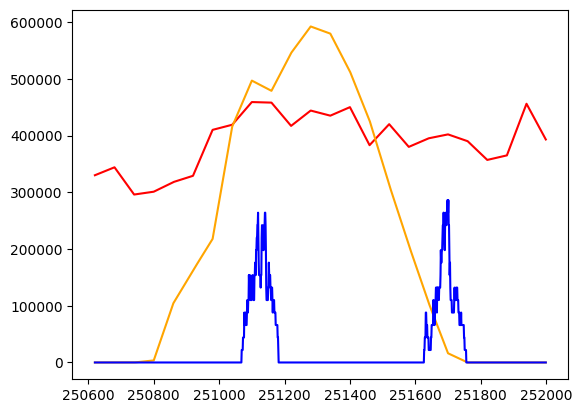

In [ ]:
#%% Représentation graphique
plt.figure()
plt.plot(v_tps_mn,Pd_mn,
        color="red",label="$P_d$")
plt.plot(v_tps_mn,Ppv, color="orange",label="$P_{pv}$")
plt.plot(v_tps_mn,P_ev, color="blue",label="$P_{ev}$")

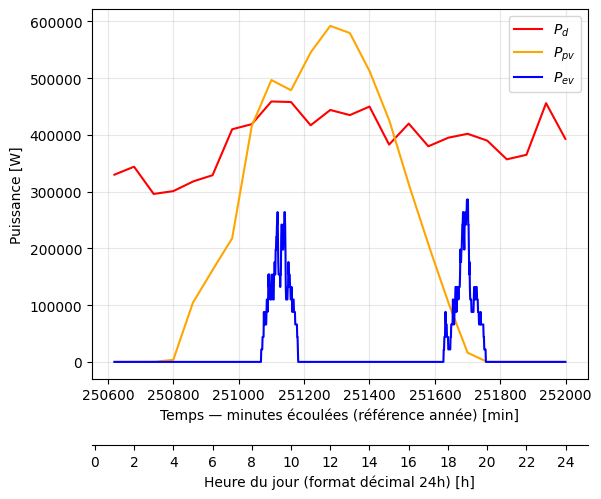

In [ ]:
#%% Représentation graphique AXIS ADITIONELS
#%% Représentation graphique (mêmes unités : W)

fig, ax = plt.subplots()

ax.plot(v_tps_mn, Pd_mn, color="red",    label="$P_d$")
ax.plot(v_tps_mn, Ppv,   color="orange", label="$P_{pv}$")
ax.plot(v_tps_mn, P_ev,  color="blue",   label="$P_{ev}$")

ax.set_ylabel("Puissance [W]")   # toutes les courbes sont en W (cohérent avec Ppv_nom en W)
ax.set_xlabel("Temps — minutes écoulées (référence année) [min]")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Sous-axe : conversion minute (année) -> heure du jour (0-24h)
def mn_to_hday(mn_abs):
    return (mn_abs - t0_midnight) / 60.0

def hday_to_mn(h_day):
    return t0_midnight + 60.0 * h_day

ax_h = ax.secondary_xaxis(-0.18, functions=(mn_to_hday, hday_to_mn))
ax_h.set_xlabel("Heure du jour (format décimal 24h) [h]")
ax_h.set_xticks(np.arange(0, 25, 2))


SUPOSICIONES

In [ ]:
import numpy as np

def battery_loss_commute(
    N_ev=50,
    capa_bat_kWh=52.0,
    autonomie_km=320.0,
    # départ le matin : 7h30-9h30 pic 8h30
    dep_home_tri=(7.5, 8.5, 9.5),
    # distance : d = 30 20 km -> (10, 30, 50) triangulaire
    dist_tri=(10.0, 30.0, 50.0),
    soc_start=1.0,          # 1.0 = 100%
    soc_min=0.10,           # 10%
    seed=None
):
    rng = np.random.default_rng(seed)

    # 1) variables aléatories
    h_dep = rng.triangular(dep_home_tri[0], dep_home_tri[1], dep_home_tri[2], size=N_ev)  # heures décimales
    d_km  = rng.triangular(dist_tri[0], dist_tri[1], dist_tri[2], size=N_ev)

    # 2) consommation moyenne (modèle simplifié du TP)
    cons_kWh_per_km = capa_bat_kWh / autonomie_km  # 52/320

    # 3) énergie consommée et perte SOC
    E_trip_kWh = d_km * cons_kWh_per_km
    soc_drop   = E_trip_kWh / capa_bat_kWh         # fraction (0-1)

    # 4) SOC à l’arrivée, limité par SOC minimum
    soc_arrival = np.clip(soc_start - soc_drop, soc_min, 1.0)

    # 5) perte en pourcentage
    drop_pct = 100.0 * (soc_start - soc_arrival)

    results = {
        "h_dep_home": h_dep,              # heure de sortie (h)
        "distance_km": d_km,              # distance (km)
        "E_trip_kWh": E_trip_kWh,         # energie consomé (kWh)
        "SOC_arrival": soc_arrival,       # SOC à l’arrivée (0-1)
        "SOC_drop_pct": drop_pct,         # % perdu (en appliquant le clip à 10 %)
        "mean_drop_pct": drop_pct.mean(), # moyenne % perdu
    }
    return results


# --- Ejemplo de uso
res = battery_loss_commute(seed=42)

print("Promedio de batería perdida (solo trayecto de ida): "
      f"{res['mean_drop_pct']:.2f} %")

# Si quieres ver el SOC final promedio:
print("SOC promedio al llegar: "
      f"{100*res['SOC_arrival'].mean():.2f} %")


Promedio de batería perdida (solo trayecto de ida): 8.78 %
SOC promedio al llegar: 91.22 %
